# Do unqiue consistency solutions exist?
Explore effect of te and ne on beta and PPB consistency equations and the solution of both. The range of te and ne was chosen based on the variety of solutions for te and ne found during UQ sampling.

In [1]:
import pandas as pd
from matplotlib import pyplot as plt
import seaborn as sns

## te and ne evaluations (not solving consistency equations)

In [2]:
df = pd.read_csv("te_ne_eval.csv")
df

,te,dene,eq_con001,eq_con002
0,10.173729,1.082827e+20,0.049316,-0.039314
1,12.133478,8.975302e+19,0.032584,-0.013078
2,10.528386,7.345730e+19,-0.321152,-0.129770
3,14.779141,1.044856e+20,0.572664,0.075324
4,9.166805,8.568001e+19,-0.300804,-0.114337
...,...,...,...,...
251,14.323720,8.596284e+19,0.186865,0.061507
252,9.437570,1.046452e+20,-0.080649,-0.046816
253,12.868539,7.317486e+19,-0.150060,-0.031701
254,11.285993,8.969031e+19,-0.052750,-0.044671


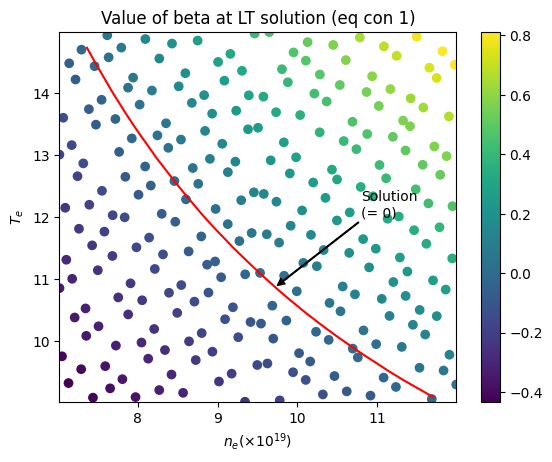

In [3]:
fig, ax = plt.subplots()
# Dividing by 1.0e19 required for triangulation algorithm to work
ne = df["dene"].to_numpy() / 1.0e19
te = df["te"].to_numpy()
beta = df["eq_con001"].to_numpy()
im = ax.scatter(ne, te, c=beta)
# Add solution line
tc_beta = ax.tricontour(ne, te, beta, levels=[0.0], colors=["red"])
fig.colorbar(im, ax=ax)
ax.set_title("Value of beta at LT solution (eq con 1)")
ax.set_xlabel(r"$n_e (\times 10^{19}$)")
ax.set_ylabel("$T_e$")
ax.annotate(
    text="Solution\n(= 0)",
    xy=(9.75, 10.9),
    xytext=(10.8, 12.0),
    arrowprops=dict(facecolor="black", width=0.5, headwidth=5, headlength=5, shrink=0),
)
fig.savefig("figs/beta.png")

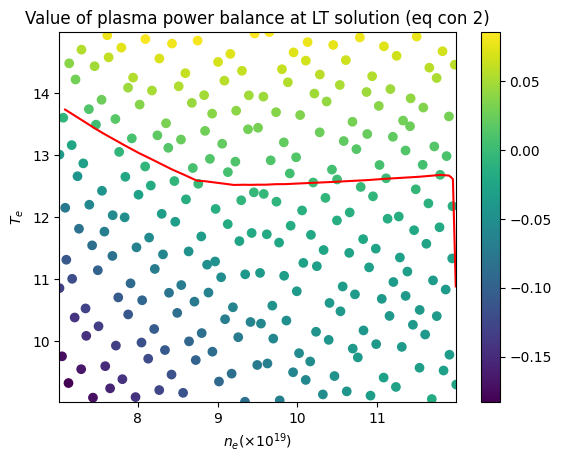

In [4]:
fig, ax = plt.subplots()
ppb = df["eq_con002"].to_numpy()
im = ax.scatter(ne, te, c=ppb)
fig.colorbar(im, ax=ax)
# Add solution line
tc_ppb = ax.tricontour(ne, te, ppb, levels=[0.0], colors=["red"])
ax.set_title("Value of plasma power balance at LT solution (eq con 2)")
ax.set_xlabel(r"$n_e (\times 10^{19}$)")
ax.set_ylabel("$T_e$")
fig.savefig("figs/ppb.png")

Strange behaviour at high ne. Artefact?

Plot both to find solution:

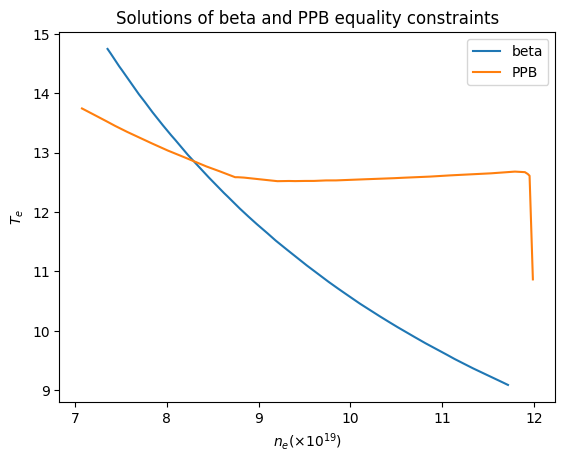

In [5]:
# beta
# Only one path (solution = 0)
path = tc_beta.get_paths()[0]
polygons = path.to_polygons()[0]
# Last values of each are the same as the first!
x_beta = polygons[:-1, 0]
y_beta = polygons[:-1, 1]
fig, ax = plt.subplots()
ax.plot(x_beta, y_beta, label="beta")

# ppb
path = tc_ppb.get_paths()[0]
polygons = path.to_polygons()[0]
x_ppb = polygons[:-1, 0]
y_ppb = polygons[:-1, 1]
ax.plot(x_ppb, y_ppb, label="PPB")

# Plot both
ax.set_xlabel(r"$n_e (\times 10^{19}$)")
ax.set_ylabel("$T_e$")
ax.legend()
ax.set_title("Solutions of beta and PPB equality constraints")
fig.savefig("figs/beta_ppb_sol.png")

Looks like a unique solution in this param space.

## Solutions of system of equality constraints
Solve both equations for te and ne using `fsolve()`.

In [6]:
sol_df = pd.read_csv("te_ne_sol.csv")
sol_df

,te,dene,eq_con001,eq_con002,dene_res,te_res
0,10.451376,8.456038e+19,-7.585266e-12,5.402123e-12,8.294981e+19,12.855976
1,14.711147,1.177444e+20,-6.505907e-14,2.464695e-14,8.294981e+19,12.855976
2,11.273911,9.629951e+19,-8.126833e-14,-2.347567e-12,8.294981e+19,12.855976
3,13.107902,8.100512e+19,-0.000000e+00,2.220446e-16,8.294981e+19,12.855976
4,9.257366,1.086830e+20,4.440892e-16,8.881784e-16,1.234270e+20,8.671523
...,...,...,...,...,...,...
59,13.236516,1.013640e+20,-1.001532e-12,9.947598e-13,8.294981e+19,12.855976
60,9.409796,8.850843e+19,-5.773160e-14,1.127987e-13,1.234270e+20,8.671523
61,14.232056,1.137963e+20,5.072609e-12,-1.664002e-12,8.294981e+19,12.855976
62,10.818407,9.869301e+19,-2.672418e-12,2.379874e-12,8.294981e+19,12.855976


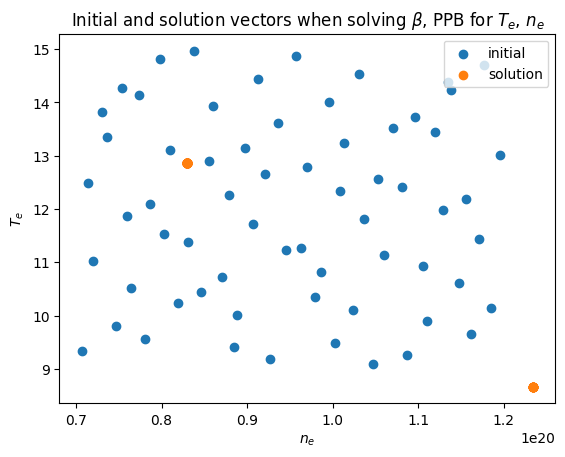

In [7]:
fig, ax = plt.subplots()
ax.scatter(sol_df["dene"], sol_df["te"], label="initial")
ax.scatter(sol_df["dene_res"], sol_df["te_res"], label="solution")
ax.set_xlabel("$n_e$")
ax.set_ylabel("$T_e$")
ax.legend(loc="upper right")
ax.set_title(r"Initial and solution vectors when solving $\beta$, PPB for $T_e$, $n_e$")
fig.savefig("figs/sols.png")

Possible to highlight which initial vectors are going to different solutions?

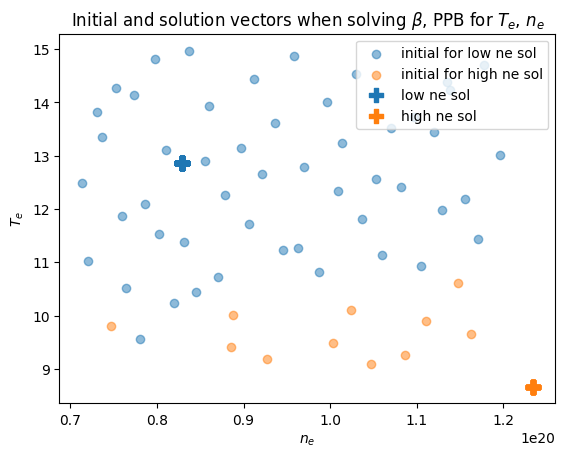

In [8]:
# Divide into high and low ne solns
high_ne_sol_df = sol_df[sol_df["dene_res"] >= 1e20]
low_ne_sol_df = sol_df[sol_df["dene_res"] < 1e20]

fig, ax = plt.subplots()
ax.scatter(
    low_ne_sol_df["dene"],
    low_ne_sol_df["te"],
    label="initial for low ne sol",
    c="tab:blue",
    alpha=0.5,
)
ax.scatter(
    high_ne_sol_df["dene"],
    high_ne_sol_df["te"],
    label="initial for high ne sol",
    c="tab:orange",
    alpha=0.5,
)
ax.scatter(
    low_ne_sol_df["dene_res"],
    low_ne_sol_df["te_res"],
    label="low ne sol",
    c="tab:blue",
    marker="P",
    s=100,
)
ax.scatter(
    high_ne_sol_df["dene_res"],
    high_ne_sol_df["te_res"],
    label="high ne sol",
    c="tab:orange",
    marker="P",
    s=100,
)
ax.set_xlabel("$n_e$")
ax.set_ylabel("$T_e$")
ax.legend(loc="upper right")
ax.set_title(r"Initial and solution vectors when solving $\beta$, PPB for $T_e$, $n_e$")
fig.savefig("figs/sols_tracked.png")

2 solutions: solution isn't unique.

Plot distribution:

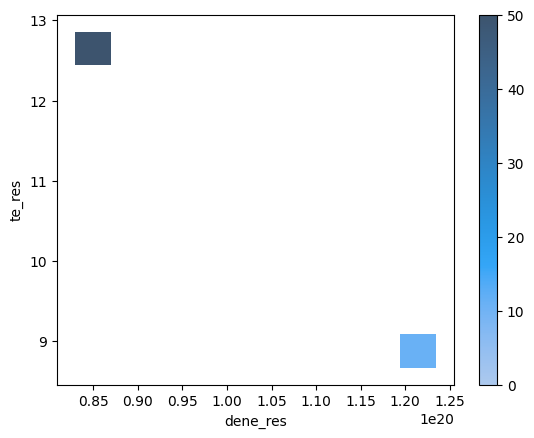

In [9]:
sns.histplot(data=sol_df, x="dene_res", y="te_res", bins=10, cbar=True)
fig.savefig("figs/sols_hist.png")

In [10]:
# Error due to not enough data?
# sns.jointplot(data=sol_df, x="dene_res", y="te_res")

Try increasing the range of te and ne further, beyond the solution range found during UQ sampling, to get more insight.

## Wide-range evaluation only (no solving)

In [11]:
wide_eval_df_raw = pd.read_csv("te_ne_eval_wide.csv")
wide_eval_df_raw

,te,dene,eq_con001,eq_con002
0,20.834741,5.452278e+19,-0.055005,0.237308
1,8.741650,2.336128e+20,1.032427,0.001507
2,26.080842,1.667275e+20,4.369751,0.577691
3,12.648618,8.952992e+19,0.080905,0.003577
4,20.295106,1.898697e+20,3.621642,0.282365
...,...,...,...,...
251,11.184163,1.891960e+20,1.223160,-0.046989
252,18.472844,9.101689e+19,0.715860,0.231028
253,5.016373,1.675944e+20,NaN,NaN
254,29.115070,2.351373e+20,8.024337,0.727084


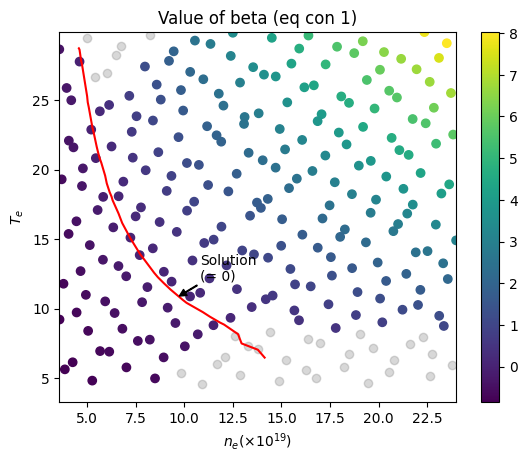

In [12]:
fig, ax = plt.subplots()
# Keep missing values for plotting
wide_eval_df_na = wide_eval_df_raw[wide_eval_df_raw.isna().any(axis=1)]
wide_eval_df = wide_eval_df_raw.dropna()
# Dividing by 1.0e19 required for triangulation algorithm to work
ne = wide_eval_df["dene"].to_numpy() / 1.0e19
te = wide_eval_df["te"].to_numpy()
beta = wide_eval_df["eq_con001"].to_numpy()
im = ax.scatter(ne, te, c=beta)
# Add solution line
tc_beta = ax.tricontour(ne, te, beta, levels=[0.0], colors=["red"])
fig.colorbar(im, ax=ax)
ax.set_title("Value of beta (eq con 1)")
ax.set_xlabel(r"$n_e (\times 10^{19}$)")
ax.set_ylabel("$T_e$")
ax.annotate(
    text="Solution\n(= 0)",
    xy=(9.75, 10.9),
    xytext=(10.8, 12.0),
    arrowprops=dict(facecolor="black", width=0.5, headwidth=5, headlength=5, shrink=0),
)
# Add missing values (e.g. crashed)
ax.scatter(
    (wide_eval_df_na["dene"] / 1.0e19),
    wide_eval_df_na["te"],
    c="grey",
    alpha=0.3,
    label="failed",
)
fig.savefig("figs/beta_wide.png")

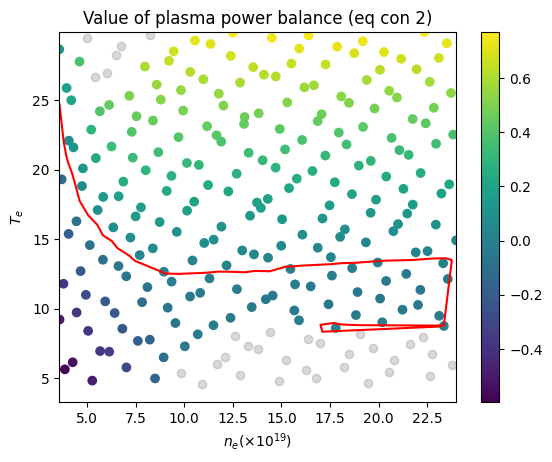

In [13]:
fig, ax = plt.subplots()
ppb = wide_eval_df["eq_con002"].to_numpy()
im = ax.scatter(ne, te, c=ppb)
fig.colorbar(im, ax=ax)
# Add solution line
tc_ppb = ax.tricontour(ne, te, ppb, levels=[0.0], colors=["red"])
ax.set_title("Value of plasma power balance (eq con 2)")
ax.set_xlabel(r"$n_e (\times 10^{19}$)")
ax.set_ylabel("$T_e$")

# Add missing values
ax.scatter(
    (wide_eval_df_na["dene"] / 1.0e19),
    wide_eval_df_na["te"],
    c="grey",
    alpha=0.3,
    label="failed",
)
fig.savefig("figs/ppb_wide.png")

## Wide solutions

In [14]:
wide_sol_df_raw = pd.read_csv("te_ne_sol_wide.csv")
wide_sol_df_raw

,te,dene,eq_con001,eq_con002,dene_res,te_res
0,15.250542,7.833216e+19,-1.224465e-12,6.035172e-13,8.294981e+19,12.855976
1,26.836500,2.054187e+20,-2.232214e-12,1.532108e-13,8.294981e+19,12.855976
2,6.760770,1.777865e+20,-3.433440e-05,8.628242e-05,NaN,NaN
3,20.177087,9.947253e+19,7.427836e-12,5.251355e-13,8.294981e+19,12.855976
4,11.969915,2.182798e+20,1.507683e-13,5.528911e-14,8.294981e+19,12.855976
...,...,...,...,...,...,...
59,18.763384,1.517787e+20,-2.720046e-14,8.215650e-15,8.294981e+19,12.855976
60,13.333412,6.520445e+19,1.107558e-12,1.043610e-14,8.294981e+19,12.855976
61,25.566911,1.947432e+20,-5.212719e-12,3.390621e-13,8.294981e+19,12.855976
62,8.279374,1.646394e+20,-1.938449e-12,4.780620e-13,1.234270e+20,8.671523


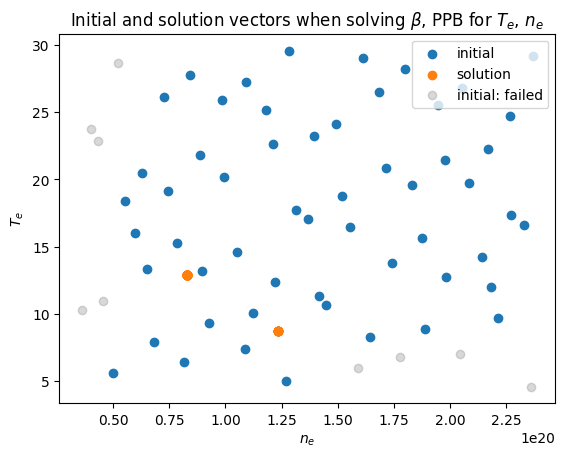

In [15]:
fig, ax = plt.subplots()
# Keep missing values for plotting
wide_sol_df_na = wide_sol_df_raw[wide_sol_df_raw.isna().any(axis=1)]
wide_sol_df = wide_sol_df_raw.dropna()

ax.scatter(wide_sol_df["dene"], wide_sol_df["te"], label="initial")
ax.scatter(wide_sol_df["dene_res"], wide_sol_df["te_res"], label="solution")
# Add missing values (e.g. crashed)
ax.scatter(
    (wide_sol_df_na["dene"]),
    wide_sol_df_na["te"],
    c="grey",
    alpha=0.3,
    label="initial: failed",
)

ax.set_xlabel("$n_e$")
ax.set_ylabel("$T_e$")
ax.legend(loc="upper right")
ax.set_title(r"Initial and solution vectors when solving $\beta$, PPB for $T_e$, $n_e$")
fig.savefig("figs/sols_wide.png")

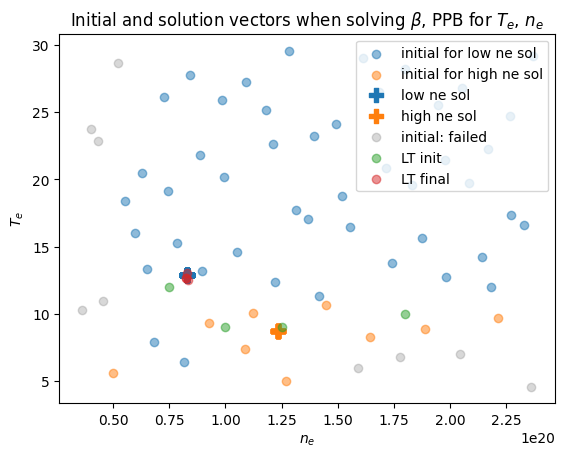

In [21]:
# Divide into high and low ne solns
high_ne_sol_df = wide_sol_df[wide_sol_df["dene_res"] >= 1e20]
low_ne_sol_df = wide_sol_df[wide_sol_df["dene_res"] < 1e20]

fig, ax = plt.subplots()
ax.scatter(
    low_ne_sol_df["dene"],
    low_ne_sol_df["te"],
    label="initial for low ne sol",
    c="tab:blue",
    alpha=0.5,
)
ax.scatter(
    high_ne_sol_df["dene"],
    high_ne_sol_df["te"],
    label="initial for high ne sol",
    c="tab:orange",
    alpha=0.5,
)
ax.scatter(
    low_ne_sol_df["dene_res"],
    low_ne_sol_df["te_res"],
    label="low ne sol",
    c="tab:blue",
    marker="P",
    s=100,
)
ax.scatter(
    high_ne_sol_df["dene_res"],
    high_ne_sol_df["te_res"],
    label="high ne sol",
    c="tab:orange",
    marker="P",
    s=100,
)
# Add missing values (e.g. crashed)
ax.scatter(
    (wide_sol_df_na["dene"]),
    wide_sol_df_na["te"],
    c="grey",
    alpha=0.3,
    label="initial: failed",
)

ax.set_xlabel("$n_e$")
ax.set_ylabel("$T_e$")
ax.set_title(r"Initial and solution vectors when solving $\beta$, PPB for $T_e$, $n_e$")

# Add in original LT solution
te_init = [12.0, 9.0, 10.0, 9.0]
ne_init = [7.5e19, 12.5e19, 18.0e19, 10.0e19]
te_final = [
    1.29977849858303252e01,
    1.26638213988933188e01,
    1.24812686317447170e01,
    1.26843660664610951e01,
]
ne_final = [
    8.27432078278004736e19,
    8.23818024412655780e19,
    8.32192904967241400e19,
    8.24268482227487539e19,
]
ax.scatter(ne_init, te_init, c="C2", label="LT init", alpha=0.5)
ax.scatter(ne_final, te_final, c="C3", label="LT final", alpha=0.5)
ax.legend(loc="upper right")

fig.savefig("figs/sols_wide_tracked.png")

2 separate solutions for beta and PPB in this case, dependent on initial vector.